In [1]:
!pip install medmnist

In [2]:
import torch
import numpy as np
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import medmnist
from medmnist import INFO

# 1. Select the dataset (BreastMNIST is great for binary anomaly detection)
data_flag = 'breastmnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

# 2. Define your image transformations
# Note: For the unsupervised part later, we will add more aggressive augmentations here!
basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# 3. Download and load the full training dataset
full_train_dataset = DataClass(split='train', transform=basic_transform, download=True)
test_dataset = DataClass(split='test', transform=basic_transform, download=True)

# 4. Create the Semi-Supervised Split (10% Labeled, 90% Unlabeled)
num_train = len(full_train_dataset)
indices = list(range(num_train))
np.random.seed(42) # For reproducibility
np.random.shuffle(indices)

# Calculate the split index
split_idx = int(np.floor(0.10 * num_train))
labeled_idx = indices[:split_idx]
unlabeled_idx = indices[split_idx:]

# Create PyTorch Subsets
labeled_dataset = Subset(full_train_dataset, labeled_idx)
unlabeled_dataset = Subset(full_train_dataset, unlabeled_idx)

# 5. Initialize the DataLoaders
# The unlabeled loader usually has a larger batch size to stabilize the unsupervised loss
labeled_loader = DataLoader(dataset=labeled_dataset, batch_size=16, shuffle=True)
unlabeled_loader = DataLoader(dataset=unlabeled_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

print(f"Total Training Images: {num_train}")
print(f"Labeled Stream Size (COGS 181): {len(labeled_dataset)}")
print(f"Unlabeled Stream Size (COGS 185): {len(unlabeled_dataset)}")

Total Training Images: 546
Labeled Stream Size (COGS 181): 54
Unlabeled Stream Size (COGS 185): 492


In [3]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Add this line right here to fix the NameError:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("--- Experiment 1: LeNet Architecture + Adam Optimizer ---")

# 1. Define LeNet (Designed specifically for 28x28 grayscale images)
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        # 1 input channel, 6 output channels, 5x5 convolution
        self.conv1 = nn.Conv2d(1, 6, 5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 2) # 2 output classes for BreastMNIST

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x



lenet_model = LeNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_lenet = optim.Adam(lenet_model.parameters(), lr=0.001)

# Training Loop for LeNet
epochs = 15
for epoch in range(epochs):
    lenet_model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in labeled_loader:
        images, labels = images.to(device), labels.to(device).squeeze().long()
        optimizer_lenet.zero_grad()
        outputs = lenet_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_lenet.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(labeled_loader):.4f}, Accuracy: {100 * correct / total:.2f}%")

--- Experiment 1: LeNet Architecture + Adam Optimizer ---
Epoch [1/15], Loss: 0.7196, Accuracy: 20.37%
Epoch [2/15], Loss: 0.6699, Accuracy: 77.78%
Epoch [3/15], Loss: 0.5836, Accuracy: 79.63%
Epoch [4/15], Loss: 0.4586, Accuracy: 79.63%
Epoch [5/15], Loss: 0.5977, Accuracy: 79.63%
Epoch [6/15], Loss: 0.5216, Accuracy: 79.63%
Epoch [7/15], Loss: 0.4717, Accuracy: 79.63%
Epoch [8/15], Loss: 0.4977, Accuracy: 79.63%
Epoch [9/15], Loss: 0.4899, Accuracy: 79.63%
Epoch [10/15], Loss: 0.4779, Accuracy: 79.63%
Epoch [11/15], Loss: 0.4807, Accuracy: 79.63%
Epoch [12/15], Loss: 0.5274, Accuracy: 79.63%
Epoch [13/15], Loss: 0.4743, Accuracy: 79.63%
Epoch [14/15], Loss: 0.4935, Accuracy: 79.63%
Epoch [15/15], Loss: 0.4339, Accuracy: 79.63%


In [4]:
from torchvision.models import resnet18, ResNet18_Weights

print("\n--- Experiment 2: ResNet-18 Architecture + SGD Optimizer ---")

# 1. Re-initialize a fresh ResNet-18
resnet_sgd_model = resnet18(weights=ResNet18_Weights.DEFAULT)
resnet_sgd_model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
resnet_sgd_model.fc = nn.Linear(resnet_sgd_model.fc.in_features, 2)
resnet_sgd_model = resnet_sgd_model.to(device)

# 2. Use SGD with Momentum instead of Adam
criterion = nn.CrossEntropyLoss()
optimizer_sgd = optim.SGD(resnet_sgd_model.parameters(), lr=0.001, momentum=0.9)

# Training Loop for ResNet with SGD
for epoch in range(epochs):
    resnet_sgd_model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in labeled_loader:
        images, labels = images.to(device), labels.to(device).squeeze().long()
        optimizer_sgd.zero_grad()
        outputs = resnet_sgd_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_sgd.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(labeled_loader):.4f}, Accuracy: {100 * correct / total:.2f}%")


--- Experiment 2: ResNet-18 Architecture + SGD Optimizer ---
Epoch [1/15], Loss: 0.9534, Accuracy: 42.59%
Epoch [2/15], Loss: 0.7234, Accuracy: 79.63%
Epoch [3/15], Loss: 0.6513, Accuracy: 79.63%
Epoch [4/15], Loss: 0.4459, Accuracy: 79.63%
Epoch [5/15], Loss: 0.4469, Accuracy: 79.63%
Epoch [6/15], Loss: 0.2430, Accuracy: 96.30%
Epoch [7/15], Loss: 0.2079, Accuracy: 90.74%
Epoch [8/15], Loss: 0.1501, Accuracy: 94.44%
Epoch [9/15], Loss: 0.1419, Accuracy: 94.44%
Epoch [10/15], Loss: 0.2500, Accuracy: 94.44%
Epoch [11/15], Loss: 0.1694, Accuracy: 96.30%
Epoch [12/15], Loss: 0.1891, Accuracy: 92.59%
Epoch [13/15], Loss: 0.0731, Accuracy: 98.15%
Epoch [14/15], Loss: 0.0410, Accuracy: 100.00%
Epoch [15/15], Loss: 0.0921, Accuracy: 98.15%


In [5]:
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet18, ResNet18_Weights

# 1. Initialize ResNet18
# Using pre-trained weights gives the network a head start on basic feature extraction
model = resnet18(weights=ResNet18_Weights.DEFAULT)

# 2. Modify Architecture for BreastMNIST
# Change the first layer to accept 1 channel (grayscale) instead of 3 (RGB)
model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
# Change the final classification layer to output 2 classes (binary classification)
model.fc = nn.Linear(model.fc.in_features, 2)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 3. Define the COGS 181 Supervised Components
# Standard Cross-Entropy Loss for classification
criterion = nn.CrossEntropyLoss()
# Adam optimizer to handle the gradient updates
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. The Baseline Training Loop
epochs = 15
print("Starting COGS 181 Baseline Training...")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Notice we are ONLY iterating over the `labeled_loader` (the 54 images)
    for images, labels in labeled_loader:
        # MedMNIST labels shape needs a squeeze to match CrossEntropy expectations
        images, labels = images.to(device), labels.to(device).squeeze().long()

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Track metrics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(labeled_loader):.4f}, Accuracy: {epoch_acc:.2f}%")

Starting COGS 181 Baseline Training...
Epoch [1/15], Loss: 0.7117, Accuracy: 68.52%
Epoch [2/15], Loss: 0.3981, Accuracy: 79.63%
Epoch [3/15], Loss: 0.5811, Accuracy: 81.48%
Epoch [4/15], Loss: 0.2686, Accuracy: 92.59%
Epoch [5/15], Loss: 0.2537, Accuracy: 90.74%
Epoch [6/15], Loss: 0.8207, Accuracy: 87.04%
Epoch [7/15], Loss: 0.2082, Accuracy: 92.59%
Epoch [8/15], Loss: 0.1622, Accuracy: 90.74%
Epoch [9/15], Loss: 0.1342, Accuracy: 96.30%
Epoch [10/15], Loss: 0.1555, Accuracy: 94.44%
Epoch [11/15], Loss: 0.0455, Accuracy: 96.30%
Epoch [12/15], Loss: 0.0683, Accuracy: 96.30%
Epoch [13/15], Loss: 0.1472, Accuracy: 96.30%
Epoch [14/15], Loss: 0.4661, Accuracy: 92.59%
Epoch [15/15], Loss: 0.5213, Accuracy: 98.15%


In [6]:
import torch.nn.functional as F
import itertools
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np

# 1. Define the augmentation for the consistency constraint
unlabeled_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15)
])

# 2. Define the hyper-parameter grid for COGS 185 Tuning
lambda_u_values = [0.1, 0.5, 1.0]
epochs_ssl = 15

print("--- COGS 185: Tuning Unsupervised Loss Weight (lambda_u) ---")

best_auc = 0
best_lambda = None
best_model_state = None

for lambda_u in lambda_u_values:
    print(f"\nTraining with lambda_u = {lambda_u}...")

    # 3. Re-initialize the model for a fair comparison from scratch!
    ssl_model = resnet18(weights=ResNet18_Weights.DEFAULT)
    ssl_model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    ssl_model.fc = nn.Linear(ssl_model.fc.in_features, 2)
    ssl_model = ssl_model.to(device)

    criterion_ssl = nn.CrossEntropyLoss()
    optimizer_ssl = optim.Adam(ssl_model.parameters(), lr=0.001)

    # 4. The Semi-Supervised Training Loop
    for epoch in range(epochs_ssl):
        ssl_model.train()
        labeled_iter = itertools.cycle(labeled_loader)

        for unlabeled_images, _ in unlabeled_loader:
            labeled_images, labels = next(labeled_iter)

            labeled_images = labeled_images.to(device)
            labels = labels.to(device).squeeze().long()
            unlabeled_images = unlabeled_images.to(device)

            optimizer_ssl.zero_grad()

            # Supervised Loss
            sup_outputs = ssl_model(labeled_images)
            loss_sup = criterion_ssl(sup_outputs, labels)

            # Unsupervised Consistency Loss
            augmented_unlabeled = unlabeled_aug(unlabeled_images)
            orig_outputs = torch.softmax(ssl_model(unlabeled_images), dim=1)
            aug_outputs = torch.softmax(ssl_model(augmented_unlabeled), dim=1)
            loss_unsup = F.mse_loss(aug_outputs, orig_outputs.detach())

            # Combined Objective
            total_loss = loss_sup + (lambda_u * loss_unsup)
            total_loss.backward()
            optimizer_ssl.step()

    # 5. Immediate Evaluation on Test Set
    ssl_model.eval()
    y_true, y_scores = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.squeeze().long()
            outputs = ssl_model(images)
            pos_probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            y_true.extend(labels.cpu().numpy())
            y_scores.extend(pos_probs)

    test_auc = roc_auc_score(y_true, y_scores)
    test_acc = accuracy_score(y_true, np.round(y_scores))
    print(f"Result for lambda_u={lambda_u}: Accuracy = {test_acc*100:.2f}%, ROC-AUC = {test_auc:.4f}")

    # Save the best model to use for Grad-CAM later
    if test_auc > best_auc:
        best_auc = test_auc
        best_lambda = lambda_u
        best_model_state = ssl_model.state_dict()

print(f"\n--- Best Hyperparameter: lambda_u = {best_lambda} with AUC = {best_auc:.4f} ---")

# 6. Load the winning weights back into the global 'model' variable
# This ensures your Grad-CAM visualization in Cell 9 still works perfectly!
model.load_state_dict(best_model_state)

--- COGS 185: Tuning Unsupervised Loss Weight (lambda_u) ---

Training with lambda_u = 0.1...
Result for lambda_u=0.1: Accuracy = 72.44%, ROC-AUC = 0.6967

Training with lambda_u = 0.5...
Result for lambda_u=0.5: Accuracy = 70.51%, ROC-AUC = 0.6142

Training with lambda_u = 1.0...
Result for lambda_u=1.0: Accuracy = 75.64%, ROC-AUC = 0.7151

--- Best Hyperparameter: lambda_u = 1.0 with AUC = 0.7151 ---


<All keys matched successfully>

--- Clinical Evaluation Metrics ---

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.56      0.43      0.49        42
Abnormal (1)       0.81      0.88      0.84       114

    accuracy                           0.76       156
   macro avg       0.68      0.65      0.66       156
weighted avg       0.74      0.76      0.75       156



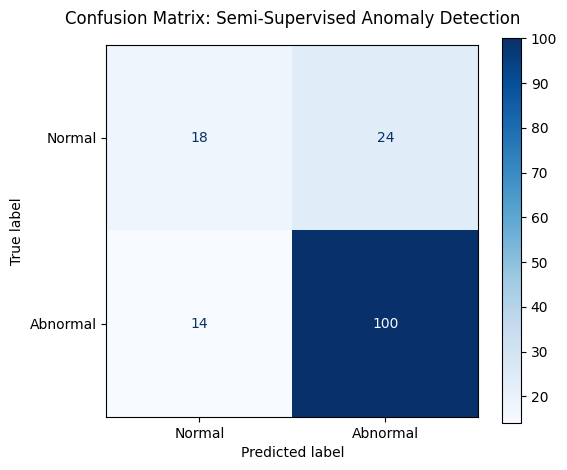

In [7]:
import torch
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("--- Clinical Evaluation Metrics ---")

# Put the winning model in evaluation mode
model.eval()
y_true_clin = []
y_pred_clin = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.squeeze().long()

        # Forward pass
        outputs = model(images)

        # Get absolute predictions (0 for Normal, 1 for Abnormal)
        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(probabilities, dim=1)

        y_true_clin.extend(labels.cpu().numpy())
        y_pred_clin.extend(predictions.cpu().numpy())

# 1. Print the Classification Report
print("\nClassification Report:")
print(classification_report(y_true_clin, y_pred_clin, target_names=['Normal (0)', 'Abnormal (1)']))

# 2. Plot the Confusion Matrix
cm = confusion_matrix(y_true_clin, y_pred_clin)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Abnormal'])

# Create a clean, professional plot
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Semi-Supervised Anomaly Detection', pad=15)
plt.show()

In [8]:
!pip install grad-cam matplotlib

Generating Fixed Grad-CAM Visualization...


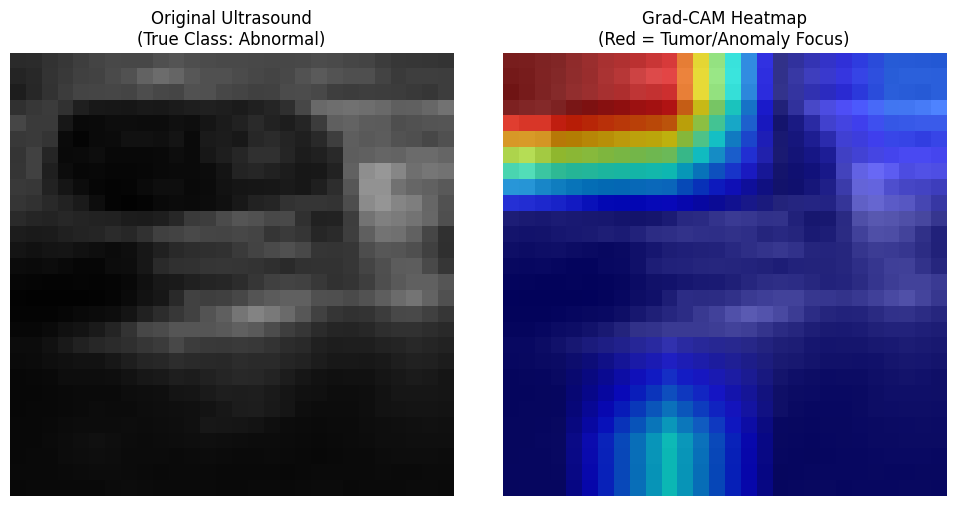

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

print("Generating Fixed Grad-CAM Visualization...")

# 1. Target an earlier layer to preserve spatial dimensions!
# layer2 leaves us with a large enough grid to map onto the 28x28 image
target_layers = [model.layer2[-1]]

# Initialize the GradCAM object
cam = GradCAM(model=model, target_layers=target_layers)

# 2. Search the test set specifically for an "Abnormal" (Class 1) scan
found_abnormal = False
for images, labels in test_loader:
    for i in range(len(labels)):
        if labels[i].item() == 1:  # Class 1 = Abnormal/Tumor
            input_tensor = images[i].unsqueeze(0).to(device)
            target_category = 1
            found_abnormal = True
            break
    if found_abnormal:
        break

# 3. Generate the raw heatmap focusing on Class 1 evidence
targets = [ClassifierOutputTarget(target_category)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

# 4. Format the original image for plotting
# Reverse the normalization to get pixels back to [0, 1] range
rgb_img = input_tensor.cpu().squeeze().numpy()
rgb_img = (rgb_img * 0.5) + 0.5
# Convert 1-channel grayscale to 3-channel RGB for the overlay
rgb_img = np.repeat(rgb_img[:, :, np.newaxis], 3, axis=2)

# 5. Overlay the heatmap onto the ultrasound scan
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# 6. Plot the results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(rgb_img)
axes[0].set_title("Original Ultrasound\n(True Class: Abnormal)")
axes[0].axis('off')

axes[1].imshow(visualization)
axes[1].set_title("Grad-CAM Heatmap\n(Red = Tumor/Anomaly Focus)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

--- Generating Latent Space Visualization (t-SNE) ---
Running t-SNE (squashing 512 dimensions down to 2)...


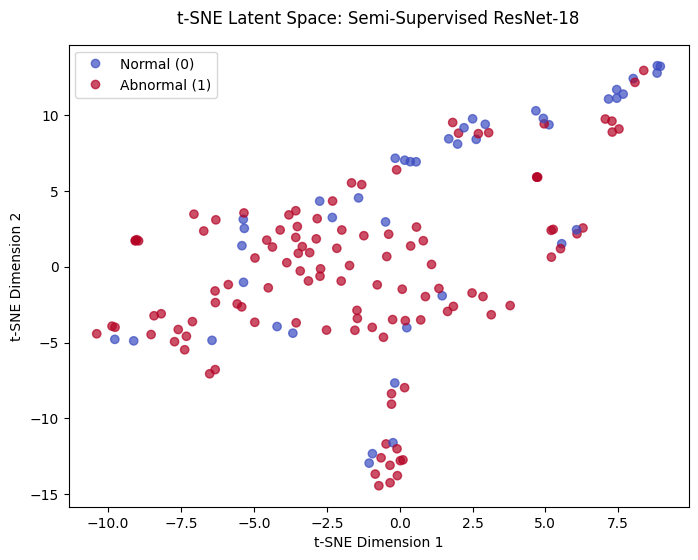

In [10]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

print("--- Generating Latent Space Visualization (t-SNE) ---")

# 1. Create a feature extractor from our winning ResNet-18 model
# This removes the final classification layer (fc) and leaves the 512-d pooling layer
feature_extractor = nn.Sequential(*list(model.children())[:-1])
feature_extractor.eval()

features = []
true_labels = []

# 2. Extract features for the entire test set
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.squeeze().long()

        # Forward pass through the feature extractor
        out = feature_extractor(images)
        # Flatten the output from [batch_size, 512, 1, 1] to [batch_size, 512]
        out = torch.flatten(out, 1)

        features.append(out.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

features = np.vstack(features)
true_labels = np.array(true_labels)

# 3. Run t-SNE dimensionality reduction
print("Running t-SNE (squashing 512 dimensions down to 2)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(features)

# 4. Plot the results
plt.figure(figsize=(8, 6))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=true_labels, cmap='coolwarm', alpha=0.7)
plt.title('t-SNE Latent Space: Semi-Supervised ResNet-18', pad=15)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

# Add a legend
classes = ['Normal (0)', 'Abnormal (1)']
plt.legend(handles=scatter.legend_elements()[0], labels=classes)
plt.show()